In [123]:
import numpy as np
import pandas as pd

import string
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets
from ipywidgets import interact
plt.rcParams['figure.figsize']=(15,5)
plt.style.use('seaborn-v0_8-colorblind')

In [ ]:
df=pd.read_csv('sentiment_drugs.csv')


In [125]:
df.shape


(160392, 9)

In [146]:
df['class_nlp_review'][:3]

0    side effect take combination bystolic 5 mg fis...
1    son halfway fourth week intuniv became concern...
2    used take another oral contraceptive 21 pill c...
Name: class_nlp_review, dtype: object

In [127]:
df.sample(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount,nlp_review,class_nlp_review
53748,203519,Nasonex,Allergic Rhinitis,"""I have Allergic Rhinitis since I was a kid un...",10,2016-02-10,12,allerg rhiniti sinc kid unfortun told cure all...,"[ ' a l l e r g i c ' , ' r h i n i t i s ' ..."
150569,99113,Lutera,Birth Control,"""I have been taking Lutera for a year. It has ...",6,2013-03-03,15,take lutera year protect pregnanc well period ...,"[ ' t a k i n g ' , ' l u t e r a ' , ' y ..."
27401,164878,Phentermine / topiramate,Weight Loss,"""This medication worked well, but not without ...",10,2016-07-04,49,medic work well without side effect learn curv...,"[ ' m e d i c a t i o n ' , ' w o r k e d ' ..."
31721,217635,Clarithromycin,Sinusitis,"""Might work for others, but I came down with m...",1,2009-04-14,49,might work other came advers side effect withi...,"[ ' m i g h t ' , ' w o r k ' , ' o t h e ..."
156194,205052,Toradol,Pain,"""Had full kidney stone blockage in ureter. Th...",9,2009-04-15,26,full kidney stone blockag uret pain sever neit...,"[ ' f u l l ' , ' k i d n e y ' , ' s t o ..."


In [128]:
print(df['date'].to_numpy())

['2012-05-20' '2010-04-27' '2009-12-14' ... '2014-03-15' '2015-09-19'
 '2014-12-13']


In [129]:
import datetime
df['date']=pd.to_datetime(df['date'],dayfirst=True,format='mixed')
print(df['date'].to_numpy())

['2012-05-20T00:00:00.000000000' '2010-04-27T00:00:00.000000000'
 '2009-12-14T00:00:00.000000000' ... '2014-03-15T00:00:00.000000000'
 '2015-09-19T00:00:00.000000000' '2014-12-13T00:00:00.000000000']


In [130]:
print(f'Number of unique Drugs present in the Dataset: {df['drugName'].nunique()}')
print(f'Number of Unique Medical Conditions present in the Dataset: {df['condition'].nunique()}')

print('\nThe time period of data colleciton:')
print('Start: ',df['date'].min())
print('End: ',df['date'].max())

Number of unique Drugs present in the Dataset: 3429
Number of Unique Medical Conditions present in the Dataset: 883

The time period of data colleciton:
Start:  2008-02-24 00:00:00
End:  2017-12-12 00:00:00


In [131]:
df.describe(include='all')

,uniqueID,drugName,condition,review,rating,date,usefulCount,nlp_review,class_nlp_review
count,160392.000000,160392,160392,160392,160392.000000,160392,160392.000000,160392,160392
unique,NaN,3429,883,112102,NaN,NaN,NaN,111737,111776
top,NaN,Levonorgestrel,Birth Control,"""Good""",NaN,NaN,NaN,good,[ ' g o o d ' ]
freq,NaN,3631,28788,33,NaN,NaN,NaN,112,112
mean,115955.891890,NaN,NaN,NaN,6.995848,2014-06-15 17:48:41.801585920,28.098577,NaN,NaN
min,2.000000,NaN,NaN,NaN,1.000000,2008-02-24 00:00:00,0.000000,NaN,NaN
25%,58063.750000,NaN,NaN,NaN,5.000000,2012-04-20 18:00:00,6.000000,NaN,NaN
50%,115843.000000,NaN,NaN,NaN,8.000000,2015-06-13 00:00:00,16.000000,NaN,NaN
75%,173826.250000,NaN,NaN,NaN,10.000000,2016-08-20 00:00:00,36.000000,NaN,NaN
max,232291.000000,NaN,NaN,NaN,10.000000,2017-12-12 00:00:00,1291.000000,NaN,NaN


In [132]:
print('Analysis on Useless Drugs')
print('-'*20)
print('The Number of Drugs with No Useful Count: ',df.loc[df['usefulCount']<=0].count()[0])
print(f'Number of Good Drugs with Lesser Useful Count: {df.loc[(df['usefulCount']<=0)&(df['rating']>=8)].shape[0]}')
print(f'Average Rating of Drugs with No Useful Count: {df.loc[df['usefulCount']<=0]['rating'].mean()}')
print('\nAnalysis on Useful Drugs')
print('-'*30)
print('The Number of Drugs with Greater than 1,000 useful counts: ',df.loc[df['usefulCount']>1000].count()[0])
print('Average Rating of Drugs with 1,000+ Useful Counts: ',df.loc[df['usefulCount']>1000]['rating'].mean())
print('\nName and Condition of these Drugs: \n\n',df.loc[df['usefulCount']>1000][['drugName','condition']].reset_index(drop=True))

Analysis on Useless Drugs
--------------------
The Number of Drugs with No Useful Count:  6215
Number of Good Drugs with Lesser Useful Count: 2593
Average Rating of Drugs with No Useful Count: 5.798712791633146

Analysis on Useful Drugs
------------------------------
The Number of Drugs with Greater than 1,000 useful counts:  4
Average Rating of Drugs with 1,000+ Useful Counts:  10.0

Name and Condition of these Drugs: 

          drugName      condition
0          Mirena  Birth Control
1      Sertraline     Depression
2  Levonorgestrel  Birth Control
3          Zoloft     Depression


C:\Users\user\AppData\Local\Temp\ipykernel_14456\3981732029.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('The Number of Drugs with No Useful Count: ',df.loc[df['usefulCount']<=0].count()[0])
C:\Users\user\AppData\Local\Temp\ipykernel_14456\3981732029.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('The Number of Drugs with Greater than 1,000 useful counts: ',df.loc[df['usefulCount']>1000].count()[0])


In [133]:
df=df.dropna()
df.isna().sum().sum()

0

In [134]:
df['review']

0         "It has no side effect, I take it in combinati...
1         "My son is halfway through his fourth week of ...
2         "I used to take another oral contraceptive, wh...
3         "This is my first time using any form of birth...
4         "Suboxone has completely turned my life around...
                                ...                        
160387    "I wrote my first report in Mid-October of 201...
160388    "I was given this in IV before surgey. I immed...
160389    "Limited improvement after 4 months, developed...
160390    "I&#039;ve been on thyroid medication 49 years...
160391    "I&#039;ve had chronic constipation all my adu...
Name: review, Length: 160392, dtype: object

In [135]:
"""
# Download required NLTK data
import nltk
nltk.download('stopwords', quiet=True)
print("NLTK stopwords downloaded successfully!")
import re
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

def nlp_pipe(data, col):
    print(f"Starting NLP processing for {len(data)} rows...")
    
    # Initialize stemmer and stopwords outside the function for efficiency
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    
    data[f'nlp_{col}'] = data[col].copy()
    
    # 1-remove html
    print("Step 1: Removing HTML tags...")
    data[f'nlp_{col}'] = data[f'nlp_{col}'].str.replace(r'<.*?>', '', regex=True)
    
    # 2-upper to lower
    print("Step 2: Converting to lowercase...")
    data[f'nlp_{col}'] = data[f'nlp_{col}'].str.lower()
    
    # 3-remove special characters but keep spaces
    print("Step 3: Removing special characters...")
    data[f'nlp_{col}'] = data[f'nlp_{col}'].str.replace(r'[^a-zA-Z0-9\s]', ' ', regex=True)
    
    # 4-normalize multiple spaces to single space
    print("Step 4: Normalizing spaces...")
    data[f'nlp_{col}'] = data[f'nlp_{col}'].str.replace(r'\s+', ' ', regex=True).str.strip()
    
    # 5-split, remove stopwords, stem words, rejoin 
    print("Step 5: Removing stopwords and stemming...")
    def remove_stop_get_stem_rejoin(text):
        if pd.isna(text):
            return ""
        words = text.split()
        filtered_words = [ps.stem(word) for word in words if word not in set(stop_words)]
        return " ".join(filtered_words)
    
    data[f'nlp_{col}'] = data[f'nlp_{col}'].apply(remove_stop_get_stem_rejoin)
    print("NLP processing completed!")
    return data


df = nlp_pipe(df, 'review')
df[['review', 'nlp_review']].head()
"""

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\user\AppData\Local\Temp\ipykernel_14456\1259123107.py:1: SyntaxWarning: invalid escape sequence '\s'
  """
C:\Users\user\AppData\Local\Temp\ipykernel_14456\1259123107.py:1: SyntaxWarning: invalid escape sequence '\s'
  """


'\n# Download required NLTK data\nimport nltk\nnltk.download(\'stopwords\', quiet=True)\nprint("NLTK stopwords downloaded successfully!")\nimport re\nfrom nltk.stem import PorterStemmer\nfrom nltk.corpus import stopwords\n\ndef nlp_pipe(data, col):\n    print(f"Starting NLP processing for {len(data)} rows...")\n    \n    # Initialize stemmer and stopwords outside the function for efficiency\n    ps = PorterStemmer()\n    stop_words = set(stopwords.words(\'english\'))\n    \n    data[f\'nlp_{col}\'] = data[col].copy()\n    \n    # 1-remove html\n    print("Step 1: Removing HTML tags...")\n    data[f\'nlp_{col}\'] = data[f\'nlp_{col}\'].str.replace(r\'<.*?>\', \'\', regex=True)\n    \n    # 2-upper to lower\n    print("Step 2: Converting to lowercase...")\n    data[f\'nlp_{col}\'] = data[f\'nlp_{col}\'].str.lower()\n    \n    # 3-remove special characters but keep spaces\n    print("Step 3: Removing special characters...")\n    data[f\'nlp_{col}\'] = data[f\'nlp_{col}\'].str.replace(r\'[

In [136]:
#df.to_csv('nlp_complete_drug.csv',index=False)

In [ ]:
"""
def punctuation_removal(messy_str):
    clean_list=[char for char in messy_str if char not in string.punctuation]
    clean_str = ''.join(clean_list)
    return clean_str

df['class_nlp_review']=df['review'].apply(punctuation_removal)
"""

In [ ]:
"""
# Ensure punkt and punkt_tab are downloaded
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.tokenize import word_tokenize

def stopwords_removal(messy_str):
    messy_str = word_tokenize(messy_str)
    return [word.lower() for word in messy_str if word.lower() not in stop_words]

df['class_nlp_review'] = df['class_nlp_review'].apply(stopwords_removal)
"""

In [ ]:
#df.to_csv('2_nlp_drugs.csv',index=False)

In [ ]:
"""
test = df.copy()
df['class_nlp_review'] = test['class_nlp_review'].apply(
	lambda x: " ".join(x) if isinstance(x, list) else ("" if pd.isna(x) else str(x))
)
df['class_nlp_review'][:5]
"""

0    side effect take combination bystolic 5 mg fis...
1    son halfway fourth week intuniv became concern...
2    used take another oral contraceptive 21 pill c...
3    first time using form birth control i039m glad...
4    suboxone completely turned life around feel he...
Name: class_nlp_review, dtype: object

In [ ]:
#df['class_nlp_review']=df['class_nlp_review'].str.replace(r'[0-9]','',regex=True)

In [148]:
df['class_nlp_review'][:5]

0    side effect take combination bystolic  mg fish...
1    son halfway fourth week intuniv became concern...
2    used take another oral contraceptive  pill cyc...
3    first time using form birth control im glad we...
4    suboxone completely turned life around feel he...
Name: class_nlp_review, dtype: object

In [ ]:
#df.to_csv('2_nlp_drugs.csv',index=False)

In [ ]:
"""
import nltk
nltk.download('vader_lexicon')
"""

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...


True

In [ ]:
"""
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()
train_sentiments=[]
for i in df['class_nlp_review']:
    train_sentiments.append(sid.polarity_scores(i).get('compound'))

train_sentiments = np.asarray(train_sentiments)
df['class_sentiment']=pd.Series(data=train_sentiments)
"""

In [ ]:
#df.to_csv('sentiment_drugs.csv',index=False)

In [154]:
grouped_df=df.groupby(['rating'])['class_sentiment'].agg(['min','mean','max'])
grouped_df

,min,mean,max
rating,,,
1,-0.9947,-0.389078,0.9848
2,-0.9944,-0.289786,0.9839
3,-0.9929,-0.219895,0.9862
4,-0.9915,-0.178072,0.9854
5,-0.9900,-0.139601,0.9877
6,-0.9902,-0.067000,0.9812
7,-0.9900,-0.012403,0.9855
8,-0.9954,0.066800,0.9867
9,-0.9912,0.122370,0.9943


In [156]:
df=df.drop(columns=['uniqueID',  'review',  'date',
       'nlp_review', 'class_nlp_review', 'class_sentiment'])
df.columns

Index(['drugName', 'condition', 'rating', 'usefulCount'], dtype='object')

In [157]:
#calculate an effective rating
min_rating=df['rating'].min()
max_rating=df['rating'].max()

def scale_rating(rating):
    rating-=min_rating
    rating=rating/(max_rating-1)
    rating*=5
    rating = int(round(rating,0))
    if int(rating) in [0,1,2]:
        return 0
    else: return 1
df['eff_score']=df['rating'].apply(scale_rating)
df.head(10)


,drugName,condition,rating,usefulCount,eff_score
0,Valsartan,Left Ventricular Dysfunction,9,27,1
1,Guanfacine,ADHD,8,192,1
2,Lybrel,Birth Control,5,17,0
3,Ortho Evra,Birth Control,8,10,1
4,Buprenorphine / naloxone,Opiate Dependence,9,37,1
5,Cialis,Benign Prostatic Hyperplasia,2,43,0
6,Levonorgestrel,Emergency Contraception,1,5,0
7,Aripiprazole,Bipolar Disorde,10,32,1
8,Keppra,Epilepsy,1,11,0
9,Ethinyl estradiol / levonorgestrel,Birth Control,8,1,1


In [159]:
df['usefulness']=df['rating']*df['usefulCount']*df['eff_score']
df.head()

,drugName,condition,rating,usefulCount,eff_score,usefulness
0,Valsartan,Left Ventricular Dysfunction,9,27,1,243
1,Guanfacine,ADHD,8,192,1,1536
2,Lybrel,Birth Control,5,17,0,0
3,Ortho Evra,Birth Control,8,10,1,80
4,Buprenorphine / naloxone,Opiate Dependence,9,37,1,333


In [161]:
mean=df['usefulness'].mean()
df[['drugName','condition','usefulness']].loc[df['usefulness']>mean].sort_values(by='usefulness',ascending=False).head(10).reset_index(drop=True)

,drugName,condition,usefulness
0,Sertraline,Depression,12910
1,Zoloft,Depression,12910
2,Levonorgestrel,Birth Control,12470
3,Mirena,Birth Control,12470
4,Zoloft,Depression,8541
5,Phentermine,Weight Loss,7960
6,Adipex-P,Weight Loss,7960
7,Implanon,Birth Control,7300
8,Viibryd,Depression,6930
9,Vilazodone,Depression,6930


In [ ]:
@interact
def check(condition = list(df['condition'].value_counts().index)):
    return df[df['condition']==condition]['eff_score'].value_counts()

interactive(children=(Dropdown(description='condition', options=('Birth Control', 'Depression', 'Pain', 'Anxie…

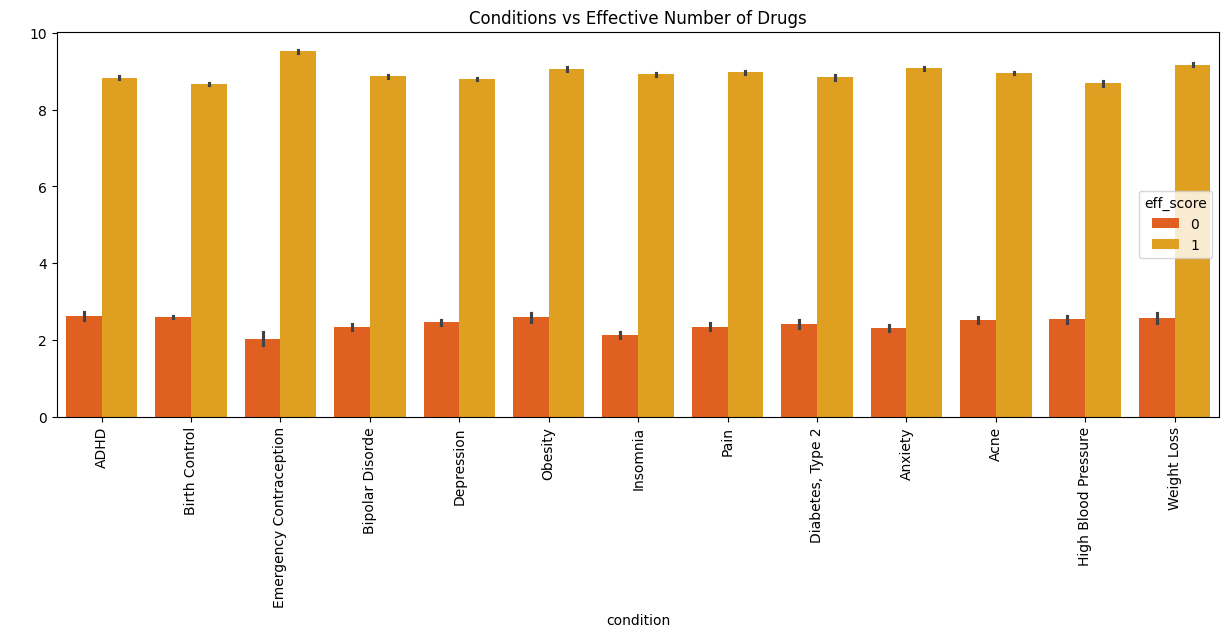

In [169]:
popular_conditions = df['condition'].value_counts().index[:13]
conditions = df.loc[df['condition'].isin(popular_conditions)]
sns.barplot(x=conditions['condition'],y=conditions['rating'],hue=df['eff_score'],
            palette='autumn')
plt.title('Conditions vs Effective Number of Drugs')
plt.xticks(rotation=90)
plt.ylabel(' ')
plt.show()

In [170]:
print('Number of conditions: ',df['condition'].nunique())
df['condition'].value_counts().head(10)

Number of conditions:  883


condition
Birth Control      28788
Depression          9069
Pain                6145
Anxiety             5903
Acne                5588
Bipolar Disorde     4224
Insomnia            3673
Weight Loss         3609
Obesity             3568
ADHD                3383
Name: count, dtype: int64

In [174]:
mean=df['usefulCount'].mean()
df[['drugName','usefulCount']].loc[df['usefulCount']>mean].sort_values(by='usefulCount', ascending=False).head(10).reset_index(drop=True)

,drugName,usefulCount
0,Zoloft,1291
1,Sertraline,1291
2,Levonorgestrel,1247
3,Mirena,1247
4,Zoloft,949
5,Adipex-P,796
6,Phentermine,796
7,Celexa,771
8,Citalopram,771
9,Implanon,730


In [175]:
df=df.drop_duplicates(keep='first')

In [180]:
@interact
def high_low_rate(condition = list(df['condition'].unique())):
    print("\n Top 5 Drugs")
    print(df.loc[df['condition']==condition][['drugName','usefulness']].sort_values(by='usefulness',
            ascending=False).head().reset_index(drop=True))
    print('\n\n Bottom 5 Drugs')
    print(df.loc[df['condition']==condition][['drugName','usefulness']].sort_values(by='usefulness',
            ascending=True).head().reset_index(drop=True))

interactive(children=(Dropdown(description='condition', options=('Left Ventricular Dysfunction', 'ADHD', 'Birt…

In [ ]:
#Next Steps; train model to predict usefulness by looking at consumer review; bag of words tfidf etcetera

In [181]:
df[['rating','usefulness']].corr()

,rating,usefulness
rating,1.000000,0.453217
usefulness,0.453217,1.000000
